In [ ]:
!pip install -q -U aeon==1.6.0

In [1]:
import io, os, re, shutil, zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binomtest
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold

In [9]:
data_url = "https://raw.githubusercontent.com/pedroterribille/Mineracao-De-Series-Temporais/tree/main/dados"
data_url = data_url.replace('github.com', 'raw.githubusercontent.com').replace('/tree/', '/').replace('/blob/', '/')

build_from_scratch = True
raw_url = "https://raw.githubusercontent.com/pedroterribille/Mineracao-De-Series-Temporais/tree/main/bruto"
raw_url = raw_url.replace('github.com', 'raw.githubusercontent.com').replace('/tree/', '/').replace('/blob/', '/')
sleep_file = "com.samsung.shealth.sleep.20260920165862.csv"
stages_file = "com.samsung.health.sleep_stage.20260920165862.csv"

min_duration = 180
epoch = 5
window_hours = 8
n_points = window_hours * 60 // epoch

classes = ['ruim', 'regular', 'bom']
score_bins = [0, 69, 84, 100]
split_date = '2025-04-01'

depth = {40001: 0, 40004: 1, 40002: 2, 40003: 3}
stage_names = ['Acordado', 'REM', 'Leve', 'Profundo']

seed = 42
np.random.seed(seed)

In [10]:
def read_table(path):
  return pd.read_csv(path, skiprows=1, index_col=False)

def to_local_time(times, offsets):
  def hours(txt):
    sign = -1 if txt[3] == '-' else 1
    return sign * (int(txt[4:6]) + int(txt[6:8]) / 60)
  return pd.to_datetime(times) + pd.to_timedelta(offsets.map(hours), unit='h')

In [11]:
def select_nights(sleep):
  p = 'com.samsung.health.sleep.'
  nights = pd.DataFrame({
      'sleep_id': sleep[p + 'datauuid'],
      'start': to_local_time(sleep[p + 'start_time'], sleep[p + 'time_offset']),
      'end': to_local_time(sleep[p + 'end_time'], sleep[p + 'time_offset']),
      'sleep_score': sleep['sleep_score']
  })
  nights['duration'] = (nights['end'] - nights['start']).dt.total_seconds() / 60
  nights['night'] = nights['end'].dt.normalize()

  nights = nights.dropna(subset=['sleep_score'])
  nights = nights.sort_values('duration').groupby('night').tail(1)
  nights = nights[nights['duration'] >= min_duration]
  return nights.sort_values('night').reset_index(drop=True)

In [12]:
def hypnogram(night, segments):
  minutes = pd.date_range(night['start'], night['end'], freq='1min', inclusive='left')
  series = pd.Series(0.0, index=minutes)
  for _, s in segments.iterrows():
    series[(series.index >= s['start']) & (series.index < s['end'])] = s['depth']
  return series

def segment_and_pad(series):
  epochs = series.resample(f'{epoch}min', origin='start').mean().values
  epochs = epochs[:n_points]
  return np.pad(epochs, (0, n_points - len(epochs)), constant_values=0.0)

def build_series(nights, stages):
  stages = stages.copy()
  stages['start'] = to_local_time(stages['start_time'], stages['time_offset'])
  stages['end'] = to_local_time(stages['end_time'], stages['time_offset'])
  stages['depth'] = stages['stage'].map(depth)
  by_session = dict(tuple(stages.groupby('sleep_id')))

  X = []
  for _, night in nights.iterrows():
    segments = by_session.get(night['sleep_id'], stages.iloc[0:0])
    X.append(segment_and_pad(hypnogram(night, segments)))
  return np.vstack(X)

In [13]:
def label_and_split(nights):
  nights = nights.copy()
  nights['classe'] = pd.cut(nights['sleep_score'], bins=score_bins, labels=classes).astype(str)
  nights['split'] = np.where(nights['night'] < pd.Timestamp(split_date), 'treino', 'teste')
  return nights

In [14]:
def save_dataset(nights, X, folder='dados'):
  shutil.rmtree(folder, ignore_errors=True)
  cols = [f't{i:03d}' for i in range(n_points)]
  minutes = np.arange(n_points) * epoch
  for i, n in nights.reset_index(drop=True).iterrows():
    path = os.path.join(folder, n['split'], n['classe'])
    os.makedirs(path, exist_ok=True)
    pd.DataFrame({'minuto_desde_inicio': minutes, 'profundidade': X[i]}).to_csv(
        os.path.join(path, f"noite_{n['night']:%Y-%m-%d}.csv"), index=False)
  table = pd.concat([
      nights[['night', 'classe', 'sleep_score', 'duration', 'split']].reset_index(drop=True)
            .rename(columns={'night': 'noite', 'duration': 'duracao_min', 'split': 'conjunto'}),
      pd.DataFrame(X.round(4), columns=cols)], axis=1)
  for s in ['treino', 'teste']:
    table[table['conjunto'] == s].drop(columns='conjunto').to_csv(os.path.join(folder, f'{s}.csv'), index=False)
  shutil.make_archive(folder, 'zip', folder)

In [15]:
if build_from_scratch:
  sleep = read_table(f'{raw_url}/{sleep_file}')
  stages = read_table(f'{raw_url}/{stages_file}')
  print(f'Sessões de sono na exportação: {len(sleep)}')

  nights = select_nights(sleep)
  print(f'Noites válidas: {len(nights)}')

  X_all = build_series(nights, stages)
  nights = label_and_split(nights)
  save_dataset(nights, X_all)
  data_url = 'dados'
else:
  print('build_from_scratch = False: conjunto carregado do repositório (data_url)')

Sessões de sono na exportação: 686
Noites válidas: 602


In [18]:
train = pd.read_csv(f'{data_url}/treino.csv', parse_dates=['noite'])
test = pd.read_csv(f'{data_url}/teste.csv', parse_dates=['noite'])

cols = [c for c in train.columns if re.fullmatch(r't\d{3}', c)]

X_train = train[cols].values.astype(float)[:, np.newaxis, :]
X_test = test[cols].values.astype(float)[:, np.newaxis, :]
y_train = np.array(train['classe'].astype(str).tolist())
y_test = np.array(test['classe'].astype(str).tolist())

print(f'Quantidade de exemplos de treino: {X_train.shape[0]} ({train.noite.min():%d/%m/%Y} a {train.noite.max():%d/%m/%Y})')
print(f'Quantidade de exemplos de teste: {X_test.shape[0]} ({test.noite.min():%d/%m/%Y} a {test.noite.max():%d/%m/%Y})')
print(f'Cada série possui {X_train.shape[2]} observações')
print(f'Classes {np.unique(y_train)}')

Quantidade de exemplos de treino: 363 (21/10/2023 a 31/03/2025)
Quantidade de exemplos de teste: 239 (01/04/2025 a 20/09/2026)
Cada série possui 96 observações
Classes ['bom' 'regular' 'ruim']


In [19]:
counts = pd.DataFrame({'treino': pd.Series(y_train).value_counts(),
                       'teste': pd.Series(y_test).value_counts()}).loc[classes]
counts.loc['total'] = counts.sum()
counts

,treino,teste
ruim,106,33
regular,153,113
bom,104,93
total,363,239


In [20]:
summary = pd.concat([train, test])
summary['pct_profundo'] = (summary[cols] == 3).mean(axis=1) * 100
summary.groupby('classe')[['sleep_score', 'duracao_min', 'pct_profundo']].mean().loc[classes].round(1)

,sleep_score,duracao_min,pct_profundo
classe,,,
ruim,60.3,337.2,6.8
regular,77.8,394.2,8.7
bom,89.2,459.7,11.8


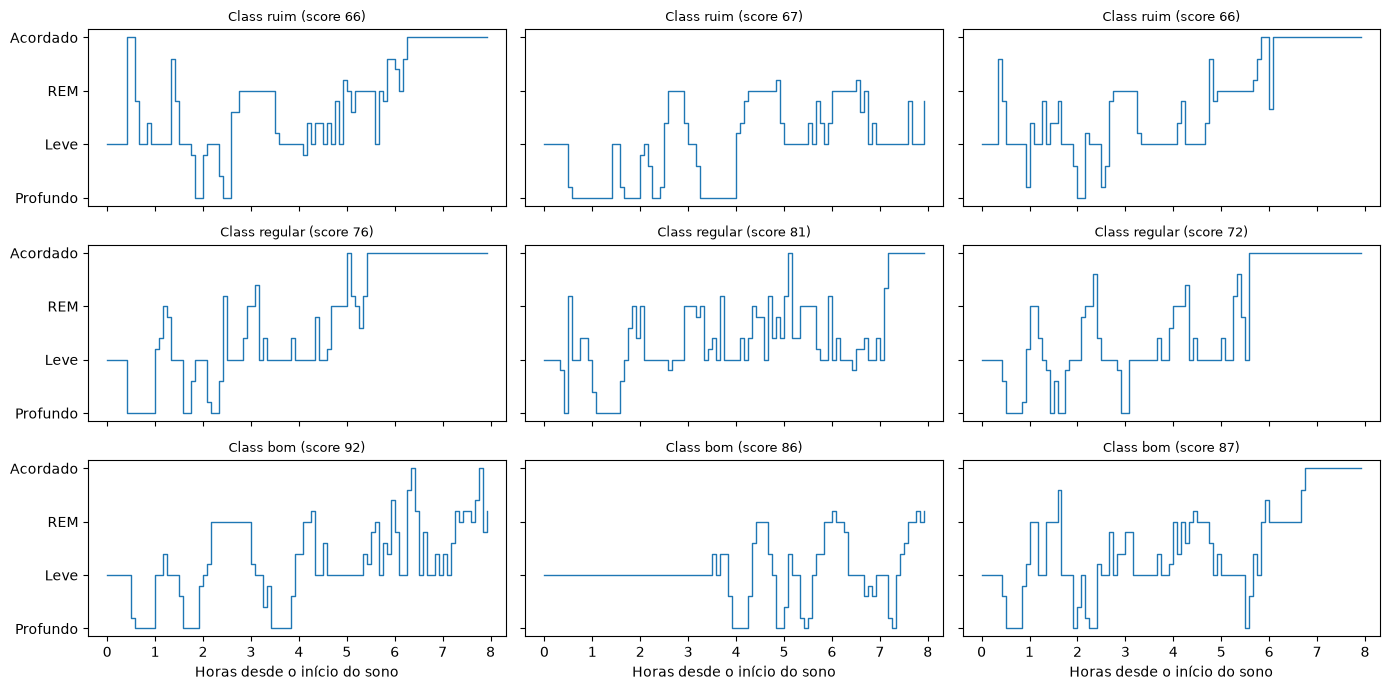

In [21]:
hours = np.arange(n_points) * epoch / 60
rng = np.random.default_rng(seed)

fig, ax = plt.subplots(3, 3, figsize=(14, 7), sharex=True, sharey=True)
for row, c in enumerate(classes):
  idx = rng.choice(np.where(y_train == c)[0], 3, replace=False)
  for col, i in enumerate(idx):
    ax[row, col].step(hours, X_train[i][0], where='post', lw=1)
    ax[row, col].set_title(f'Class {c} (score {train.sleep_score.iloc[i]:.0f})', fontsize=9)
    ax[row, col].set_yticks(range(4), stage_names)
    ax[row, col].invert_yaxis()
for a in ax[-1]:
  a.set_xlabel('Horas desde o início do sono')
plt.tight_layout()
plt.show()

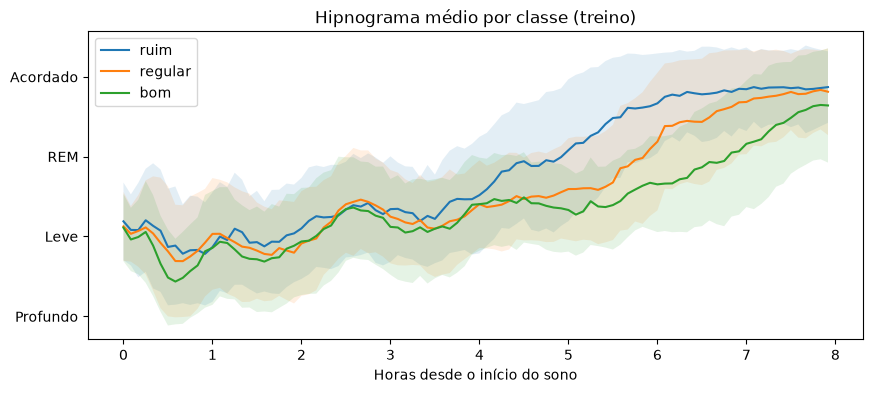

In [22]:
plt.figure(figsize=(10, 4))
for c in classes:
  series = X_train[y_train == c, 0]
  mean, std = series.mean(axis=0), series.std(axis=0)
  plt.plot(hours, mean, label=c)
  plt.fill_between(hours, mean - std, mean + std, alpha=0.12)
plt.yticks(range(4), stage_names)
plt.gca().invert_yaxis()
plt.xlabel('Horas desde o início do sono')
plt.title('Hipnograma médio por classe (treino)')
plt.legend()
plt.show()

Janela 0.00 (0 min): acurácia LOO = 0.496
Janela 0.05 (24 min): acurácia LOO = 0.587
Janela 0.10 (48 min): acurácia LOO = 0.598
Janela 0.20 (96 min): acurácia LOO = 0.512
Janela 0.30 (144 min): acurácia LOO = 0.457
Janela 1.00 (480 min): acurácia LOO = 0.446

Janela selecionada: 0.1


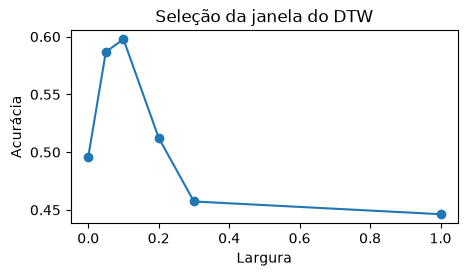

In [24]:
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from aeon.distances import dtw_pairwise_distance

windows = [0.0, 0.05, 0.10, 0.20, 0.30, 1.0]
loo_acc = {}
for w in windows:
  D = dtw_pairwise_distance(X_train, window=w)
  np.fill_diagonal(D, np.inf)
  loo_acc[w] = np.mean(y_train[D.argmin(axis=1)] == y_train)
  print(f'Janela {w:.2f} ({w * window_hours * 60:.0f} min): acurácia LOO = {loo_acc[w]:.3f}')

best_window = max(loo_acc, key=loo_acc.get)
print(f'\nJanela selecionada: {best_window}')

plt.figure(figsize=(5, 2.5))
plt.plot(list(loo_acc.keys()), list(loo_acc.values()), marker='o')
plt.xlabel('Largura')
plt.ylabel('Acurácia')
plt.title('Seleção da janela do DTW')
plt.show()

Acurácia 1NN (dtw): 0.5355648535564853


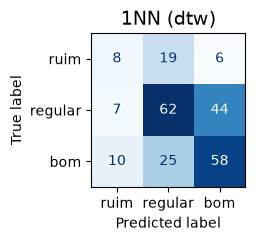

In [25]:
knn = KNeighborsTimeSeriesClassifier(distance='dtw', n_neighbors=1, distance_params={'window': best_window})
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

print(f'Acurácia 1NN (dtw): {accuracy_score(y_test, knn_preds)}')
cm = confusion_matrix(y_test, knn_preds, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(3, 2))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("1NN (dtw)", fontsize=14)
plt.show()

In [26]:
from aeon.classification.convolution_based import MiniRocketClassifier

kernels = [1000, 5000, 10000]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
cv_acc = {}
for k in kernels:
  scores = []
  for tr_idx, val_idx in skf.split(X_train, y_train):
    model = MiniRocketClassifier(n_kernels=k, random_state=seed)
    model.fit(X_train[tr_idx], y_train[tr_idx])
    scores.append(accuracy_score(y_train[val_idx], model.predict(X_train[val_idx])))
  cv_acc[k] = np.mean(scores)
  print(f'n_kernels = {k}: acurácia CV = {cv_acc[k]:.3f} (±{np.std(scores):.3f})')

best_k = max(cv_acc, key=cv_acc.get)
print(f'\nNúmero de kernels selecionado: {best_k}')

n_kernels = 1000: acurácia CV = 0.663 (±0.093)
n_kernels = 5000: acurácia CV = 0.658 (±0.067)
n_kernels = 10000: acurácia CV = 0.628 (±0.061)

Número de kernels selecionado: 1000


Acurácia MiniROCKET: 0.6861924686192469


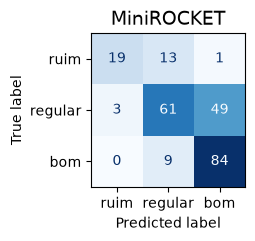

In [27]:
minirocket = MiniRocketClassifier(n_kernels=best_k, random_state=seed)
minirocket.fit(X_train, y_train)
minirocket_preds = minirocket.predict(X_test)

print(f'Acurácia MiniROCKET: {accuracy_score(y_test, minirocket_preds)}')
cm = confusion_matrix(y_test, minirocket_preds, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(3, 2))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("MiniROCKET", fontsize=14)
plt.show()

In [29]:
for name, preds in [('1NN-DTW', knn_preds), ('MiniROCKET', minirocket_preds)]:
  print(f'{name}')
  print(classification_report(y_test, preds, labels=classes, digits=3, zero_division=0))

1NN-DTW
              precision    recall  f1-score   support

        ruim      0.320     0.242     0.276        33
     regular      0.585     0.549     0.566       113
         bom      0.537     0.624     0.577        93

    accuracy                          0.536       239
   macro avg      0.481     0.472     0.473       239
weighted avg      0.530     0.536     0.530       239

MiniROCKET
              precision    recall  f1-score   support

        ruim      0.864     0.576     0.691        33
     regular      0.735     0.540     0.622       113
         bom      0.627     0.903     0.740        93

    accuracy                          0.686       239
   macro avg      0.742     0.673     0.684       239
weighted avg      0.711     0.686     0.678       239



In [30]:
order = {c: i for i, c in enumerate(classes)}
for name, preds in [('1NN-DTW', knn_preds), ('MiniROCKET', minirocket_preds)]:
  gap = np.abs(np.array([order[p] for p in preds]) - np.array([order[y] for y in y_test]))
  print(f'{name}: {np.sum(gap == 1)} erros entre classes vizinhas | {np.sum(gap == 2)} erros extremos')

1NN-DTW: 95 erros entre classes vizinhas | 16 erros extremos
MiniROCKET: 74 erros entre classes vizinhas | 1 erros extremos


In [33]:
limits = np.array([69.5, 84.5])
test['dist_limite'] = np.abs(test['sleep_score'].values[:, None] - limits).min(axis=1)
test['faixa'] = pd.cut(test['dist_limite'], [0, 3, 7, 100], labels=['até 3 pontos', '3 a 7 pontos', 'mais de 7 pontos'])
test['acerto_1nn_dtw'] = knn_preds == y_test
test['acerto_minirocket'] = minirocket_preds == y_test

test.groupby('faixa', observed=True).agg(
    noites=('classe', 'size'),
    acuracia_1nn_dtw=('acerto_1nn_dtw', 'mean'),
    acuracia_minirocket=('acerto_minirocket', 'mean')).round(3)

,noites,acuracia_1nn_dtw,acuracia_minirocket
faixa,,,
até 3 pontos,93,0.538,0.634
3 a 7 pontos,99,0.515,0.657
mais de 7 pontos,47,0.574,0.851
